In [2]:
import os, random
import numpy as np
from matplotlib import pyplot as plt
import cv2

In [3]:
IMAGES_PATH='./images/'
images=os.listdir(IMAGES_PATH)
print(IMAGES_PATH, len(images))

./images/ 57


In [18]:
print(images)

['316621403173337.jpg', '1906358932865344.jpg', '2906972246218105.jpg', '381983746312130.jpg', '471551644079480.jpg', '1436421286690304.jpg', '1107566246415365.jpg', '464727507956800.jpg', '464708274639748.jpg', '3576165379154064.jpg', '338510417707516.jpg', '238860487989023.jpg', '1005521353521146.jpg', '1095395410955679.jpg', '1881066002068687.jpg', '4193770030702688.jpg', '1332041480516065.jpg', '146102127411285.jpg', '2934649763445834.jpg', '204543651249633.jpg', '161655535875500.jpg', '763542721017806.jpg', '3817092555085233.jpg', '881635402400390.jpg', '133358495446494.jpg', '143578851111106.jpg', '503057221119154.jpg', '782168989340713.jpg', '900015563890465.jpg', '318076143002057.jpg', '141048531366793.jpg', '3705203162940296.jpg', '376324420364025.jpg', '242797374305660.jpg', '499335831485892.jpg', '325846765629059.jpg', '813089616302447.jpg', '329926648464757.jpg', '513028209854980.jpg', '784807075758154.jpg', '302002244631991.jpg', '294316405676472.jpg', '227514145839884.jpg

816243815992586.jpg


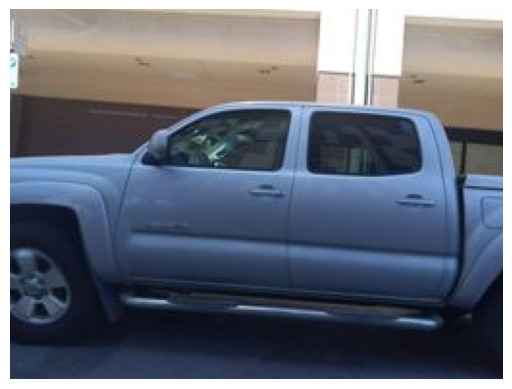

In [17]:
test_image_path = random.choice(images)
print(test_image_path)
example_image=cv2.imread(IMAGES_PATH + test_image_path)
def display(img):    
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
display(example_image)

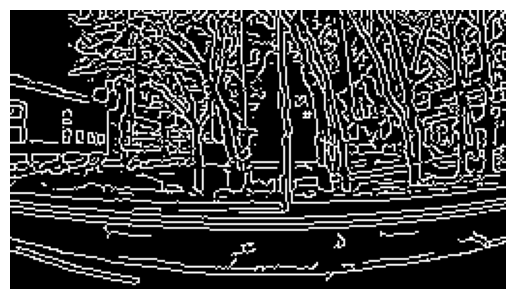

In [6]:
gray = cv2.cvtColor(src=example_image, code=cv2.COLOR_BGR2GRAY)
blur_gray = cv2.GaussianBlur(src=gray, ksize=(5, 5), sigmaX=0)
edges = cv2.Canny(image=blur_gray, threshold1=20, threshold2=50, apertureSize=3)
display(edges)

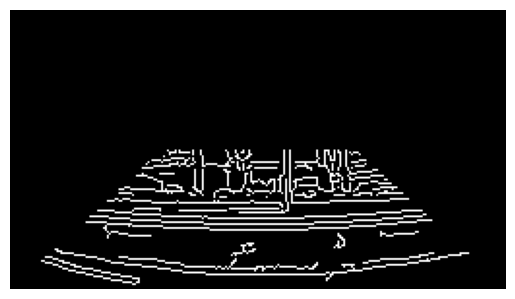

In [7]:
mask = np.zeros_like(edges)
height, width = edges.shape
polygon = np.array([[
    (0, height),
    (width, height),
    (width // 2 + 50, height // 2),
    (width // 2 - 50, height // 2)
]], np.int32)
cv2.fillPoly(mask, polygon, 255)
masked_edges = cv2.bitwise_and(edges, mask)

display(masked_edges)

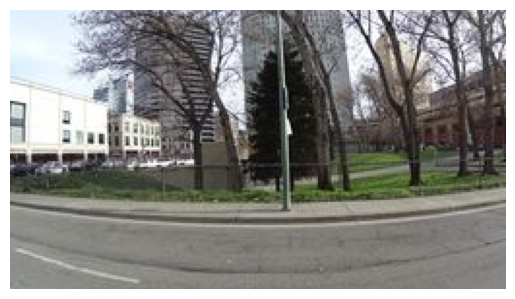

In [8]:
lines = cv2.HoughLinesP(masked_edges,
                        rho=2,
                        theta=np.pi/180,
                        threshold=70,
                        minLineLength=100,
                        maxLineGap=50)

RED=(0, 0, 255)
THICKNESS=1
        
if lines is not None:
    filtered_lines = []
    for line in lines:
        x1, y1, x2, y2 = line[0]

        # Compute angle in degrees
        angle = np.degrees(np.arctan2((y2 - y1), (x2 - x1)))

        # Keep only slanted lines (e.g. between 15° and 60°, or -60° and -15°)
        if (15 < abs(angle) < 60):
            filtered_lines.append(line)

    # Draw filtered lines
    line_img = np.copy(example_image)
    for line in filtered_lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), RED, THICKNESS)
        
display(line_img)